In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import h5py
from scipy.io import loadmat

cm_data = [[0.2081, 0.1663, 0.5292], [0.2116238095, 0.1897809524, 0.5776761905],
 [0.212252381, 0.2137714286, 0.6269714286], [0.2081, 0.2386, 0.6770857143],
 [0.1959047619, 0.2644571429, 0.7279], [0.1707285714, 0.2919380952,
  0.779247619], [0.1252714286, 0.3242428571, 0.8302714286],
 [0.0591333333, 0.3598333333, 0.8683333333], [0.0116952381, 0.3875095238,
  0.8819571429], [0.0059571429, 0.4086142857, 0.8828428571],
 [0.0165142857, 0.4266, 0.8786333333], [0.032852381, 0.4430428571,
  0.8719571429], [0.0498142857, 0.4585714286, 0.8640571429],
 [0.0629333333, 0.4736904762, 0.8554380952], [0.0722666667, 0.4886666667,
  0.8467], [0.0779428571, 0.5039857143, 0.8383714286],
 [0.079347619, 0.5200238095, 0.8311809524], [0.0749428571, 0.5375428571,
  0.8262714286], [0.0640571429, 0.5569857143, 0.8239571429],
 [0.0487714286, 0.5772238095, 0.8228285714], [0.0343428571, 0.5965809524,
  0.819852381], [0.0265, 0.6137, 0.8135], [0.0238904762, 0.6286619048,
  0.8037619048], [0.0230904762, 0.6417857143, 0.7912666667],
 [0.0227714286, 0.6534857143, 0.7767571429], [0.0266619048, 0.6641952381,
  0.7607190476], [0.0383714286, 0.6742714286, 0.743552381],
 [0.0589714286, 0.6837571429, 0.7253857143],
 [0.0843, 0.6928333333, 0.7061666667], [0.1132952381, 0.7015, 0.6858571429],
 [0.1452714286, 0.7097571429, 0.6646285714], [0.1801333333, 0.7176571429,
  0.6424333333], [0.2178285714, 0.7250428571, 0.6192619048],
 [0.2586428571, 0.7317142857, 0.5954285714], [0.3021714286, 0.7376047619,
  0.5711857143], [0.3481666667, 0.7424333333, 0.5472666667],
 [0.3952571429, 0.7459, 0.5244428571], [0.4420095238, 0.7480809524,
  0.5033142857], [0.4871238095, 0.7490619048, 0.4839761905],
 [0.5300285714, 0.7491142857, 0.4661142857], [0.5708571429, 0.7485190476,
  0.4493904762], [0.609852381, 0.7473142857, 0.4336857143],
 [0.6473, 0.7456, 0.4188], [0.6834190476, 0.7434761905, 0.4044333333],
 [0.7184095238, 0.7411333333, 0.3904761905],
 [0.7524857143, 0.7384, 0.3768142857], [0.7858428571, 0.7355666667,
  0.3632714286], [0.8185047619, 0.7327333333, 0.3497904762],
 [0.8506571429, 0.7299, 0.3360285714], [0.8824333333, 0.7274333333, 0.3217],
 [0.9139333333, 0.7257857143, 0.3062761905], [0.9449571429, 0.7261142857,
  0.2886428571], [0.9738952381, 0.7313952381, 0.266647619],
 [0.9937714286, 0.7454571429, 0.240347619], [0.9990428571, 0.7653142857,
  0.2164142857], [0.9955333333, 0.7860571429, 0.196652381],
 [0.988, 0.8066, 0.1793666667], [0.9788571429, 0.8271428571, 0.1633142857],
 [0.9697, 0.8481380952, 0.147452381], [0.9625857143, 0.8705142857, 0.1309],
 [0.9588714286, 0.8949, 0.1132428571], [0.9598238095, 0.9218333333,
  0.0948380952], [0.9661, 0.9514428571, 0.0755333333],
 [0.9763, 0.9831, 0.0538]]

parula_map = LinearSegmentedColormap.from_list('parula', cm_data)
parula_map.set_under(cm_data[0])

## Load WKBeam QL diffusion files

In [3]:
output_dir = '/home/devlamin/WanKenoBEAM/StandardCases/TCV_88612_1.25_fluct/output'

filename_M    = '/home/devlamin/WKbeam_simulations/TCV_88612_1.25_QL_coupled_adaptive/iter_0/output/QLdiff_L4.h5'
filename_EDF  = '/home/devlamin/WKbeam_simulations/TCV_88612_1.25_QL_coupled_adaptive/iter_1/output/QLdiff_L4.h5'
filename_C3PO = '/home/devlamin/WKbeam_simulations/TCV_88612_1.25_QL_coupled_adaptive/iter_3/output/QLdiff_L4.h5'

# beta = v_th_ref / c  (converts p/p_th -> p_mc = p/(m_e c))
beta = 0.06808653873838687
grid = 'hh'   # 'hh' | 'hw' | 'wh'

def load_qldiff(filename, grid):
    """Load a WKBeam QL diffusion HDF5 file.
    Returns DRF_pp of shape (n_ksi0, n_p, n_psi), summed over harmonics.
    """
    dataname = 'DRF0_' + grid
    with h5py.File(filename, 'r') as f:
        psi        = f['psi'][()]
        p_norm_h   = f['p_norm_h'][()]
        p_norm_w   = f['p_norm_w'][()]
        ksi0_h     = f['ksi0_h'][()]
        ksi0_w     = f['ksi0_w'][()]
        harmonics  = f['harmonics'][()]
        Trapksi0_h = f['Trapksi0_h'][()]
        Trapksi0_w = f['Trapksi0_w'][()]
        rho_abs    = f['rho_abs'][()]
        dP_drho    = f['dP_drho'][()]
        sparse     = f[dataname + '_sparse'][()]
        mask       = f['mask_' + dataname][()]

    if grid == 'hh':
        p_norm, ksi0, Trapksi0 = p_norm_h, ksi0_h, Trapksi0_h
    elif grid == 'hw':
        p_norm, ksi0, Trapksi0 = p_norm_h, ksi0_w, Trapksi0_w
    elif grid == 'wh':
        p_norm, ksi0, Trapksi0 = p_norm_w, ksi0_h, Trapksi0_h

    flat = np.zeros(len(p_norm) * len(ksi0) * len(psi) * len(harmonics))
    flat[mask] = sparse
    arr = flat.reshape((len(p_norm), len(ksi0), len(psi), len(harmonics)), order='F')
    arr = np.transpose(arr, (1, 0, 2, 3))    # -> (ksi0, p, psi, harm)

    _, Ksi0 = np.meshgrid(p_norm, ksi0)
    DRF_pp = arr.sum(axis=3) * (1 - Ksi0[:, :, np.newaxis]**2)   # (ksi0, p, psi)

    return dict(
        psi=psi, p_norm=p_norm, p_mc=p_norm*beta, ksi0=ksi0,
        harmonics=harmonics, Trapksi0=Trapksi0,
        rho_abs=rho_abs, dP_drho=dP_drho,
        DRF_pp=DRF_pp,
    )

data_M    = load_qldiff(filename_M,    grid)
data_EDF  = load_qldiff(filename_EDF,  grid)
data_C3PO = load_qldiff(filename_C3PO, grid)

for label, d in [('M', data_M), ('1', data_EDF), ('4', data_C3PO)]:
    print(f'WKBeam {label:<5}  absorption={np.trapz(d["dP_drho"][:,0], d["rho_abs"]):.4f} MW  '
          f'DRF_pp max={np.max(d["DRF_pp"]):.3f}')

WKBeam M      absorption=0.8845 MW  DRF_pp max=2.050
WKBeam 1      absorption=0.8850 MW  DRF_pp max=6.687
WKBeam 4      absorption=0.8850 MW  DRF_pp max=4.863


## Load LUKE-C3PO reference D_pp

In [4]:
c3po_file = '/home/devlamin/BOBAFET/C3PO_Lin_1it_EDF.mat' #'/home/devlamin/BOBAFET/C3PO_Lin_EDF.mat'

edf = loadmat(c3po_file, struct_as_record=False, squeeze_me=True)['EDF']

# LUKE stores DRF_pp as (n_p, n_xi, n_psi); transpose to (n_xi, n_p, n_psi)
# to match WKBeam's (ksi0, p, psi) convention.
# Grids are identical to WKBeam's p_norm_h / ksi0_h (verified: max diff = 0).
luke_c3po = dict(
    p      = edf.p,
    xi     = edf.xi,
    psi    = edf.psi,
    DRF_pp = np.transpose(edf.DRF_pp, (1, 0, 2)),   # (xi, p, psi)
    absorption = edf.abs,
)

print('LUKE-C3PO DRF_pp shape:', luke_c3po['DRF_pp'].shape,
      ' max:', np.max(luke_c3po['DRF_pp']))

LUKE-C3PO DRF_pp shape: (122, 100, 16)  max: 6.8092717310232675


## Absorption profiles

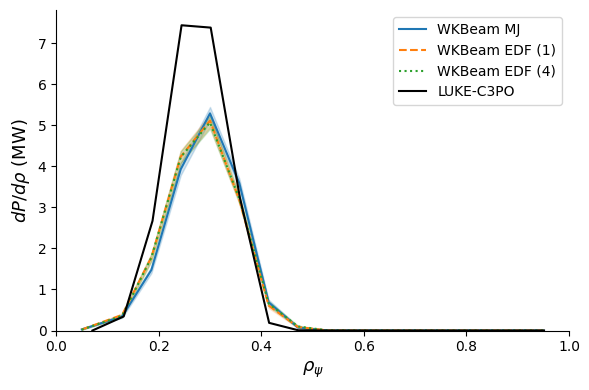

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

styles = [
    (data_M,    'WKBeam MJ',         'C0', '-'),
    (data_EDF,  'WKBeam EDF (1)', 'C1', '--'),
    (data_C3PO, 'WKBeam EDF (4)', 'C2', ':'),
]
for d, label, color, ls in styles:
    ax.plot(d['rho_abs'], d['dP_drho'][:,0], label=label, color=color, ls=ls)
    ax.fill_between(d['rho_abs'],
        d['dP_drho'][:,0] - d['dP_drho'][:,1],
        d['dP_drho'][:,0] + d['dP_drho'][:,1],
        alpha=0.2, color=color)
rho_c3po = np.sqrt(luke_c3po['psi'])
dPdrho_c3po = luke_c3po['absorption'] / np.gradient(rho_c3po) * 2 * np.pi /0.88 
ax.plot(rho_c3po, dPdrho_c3po, label='LUKE-C3PO', color='k', ls='-')

ax.set_xlabel(r'$\rho_{\psi}$', fontsize=13)
ax.set_ylabel(r'$dP/d\rho$ (MW)', fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0)
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(output_dir + '/QL_absorption_comparison.png', dpi=150)
plt.show()

## Peak D_pp vs rho

In [6]:
def integrate_phasespace(DRF_pp, p_norm, ksi0, psi):
    """Integrate DRF_pp over p and ksi0 to get a function of psi only."""
    # Integration over p:
    p_3D = p_norm[np.newaxis, :, np.newaxis]   # (1, p, 1)
    Drf_pInt = np.trapz(DRF_pp*p_3D**2, x=p_norm, axis=1)   # (ksi0, psi)
    # Integration over ksi0:
    M_psi = np.trapz(Drf_pInt, x=ksi0, axis=0)   # (psi,)
    return M_psi

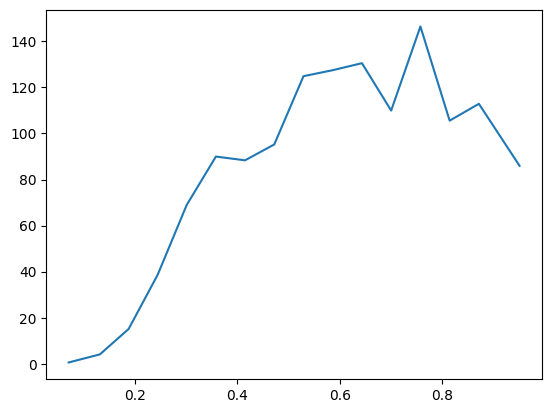

In [7]:
M_psi = integrate_phasespace(data_M['DRF_pp'], data_M['p_norm'], data_M['ksi0'], data_M['psi'])
plt.plot(np.sqrt(data_M['psi']), M_psi)

In [ ]:
import QL_diffusion.QL_diff_aux as aux
from CommonModules.input_data import InputData 
from CommonModules.PlasmaEquilibrium import TokamakEquilibrium

filename = '/home/devlamin/WKbeam_simulations/TCV_88612_1.25_QL_coupled/iter_0/output/L4_binned.hdf5'

filename_Eq = '/home/devlamin/WKbeam_simulations/TCV_88612_1.25_QL_coupled/iter_0/RayTracing_L4.txt'

WhatToResolve, FreqGHz, mode, Wfct, Absorption, EnergyFlux, rhobins, thetabins, Nparallelbins, Nperpbins = aux.read_h5file(filename)


d_rho = np.diff(rhobins)
rho = 0.5 * (rhobins[1:] + rhobins[:-1])

psibins = rhobins**2
d_psi = np.diff(psibins)
psi = 0.5 * (psibins[1:] + psibins[:-1])

d_theta = np.diff(thetabins)[0]
theta = 0.5 * (thetabins[1:] + thetabins[:-1])

d_npar = np.diff(Nparallelbins)[0]
Npar = 0.5 * (Nparallelbins[1:] + Nparallelbins[:-1])

d_nperp = np.diff(Nperpbins)[0]
Nperp = 0.5 * (Nperpbins[1:] + Nperpbins[:-1])

idata = InputData(filename_Eq)
Eq = TokamakEquilibrium(idata)

dV_N = 2 * np.pi * Nperp * d_nperp * d_npar
ptV = np.zeros((len(rho), len(theta)))
R = np.zeros((len(rho), len(theta)))
Z = np.zeros((len(rho), len(theta)))

for l, psi_val in enumerate(psi):
    for t, theta_val in enumerate(theta):
        ptV[l, t] = 2*np.pi * 1e-6 * d_psi[l] * d_theta * Eq.volume_element_J(theta_val, psi_val)
        R[l, t], Z[l, t] = Eq.flux_to_grid_coord(psi_val, theta_val)
# As in notes, (called W_KB in the notes), we need Wfct * 4pi/c /(dV_N)
Edens =  Wfct[:,:,:,:,0] / np.sum(ptV, axis=1)[:, None, None, None]
Edens /= dV_N[None, None, None, :] # Energy density in k-space
Edens *= 4*np.pi /c * 1e6 
# With this, Edens_N is k-space energy density in J/N^2
#---Added factor for now to match C3PO output---#


pV = np.sum(ptV, axis=1)
plt.figure()
plt.scatter(psi, pV/d_psi)

ModuleNotFoundError: No module named 'WanKenoBEAM'

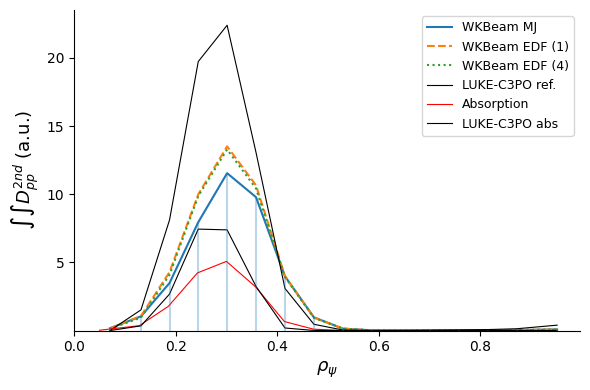

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
# Only for first harmonic, so explude p greater than 10
p_max = 8
powers = [0.8815, 0.8815, 2.87901, 2.09385]
#powers = np.ones(len(datasets))

# Maxwellian
p_mask_M    = np.where(data_M['p_norm'] < p_max)[0]
DRF_int_M = integrate_phasespace(data_M['DRF_pp'][:, p_mask_M, :], data_M['p_norm'][p_mask_M], data_M['ksi0'], data_M['psi'])
# EDFs
p_mask_EDF  = np.where(data_EDF['p_norm'] < p_max)[0]
DRF_int_EDF = integrate_phasespace(data_EDF['DRF_pp'][:, p_mask_EDF, :], data_EDF['p_norm'][p_mask_EDF], data_EDF['ksi0'], data_EDF['psi'])
p_mask_C3PO = np.where(data_C3PO['p_norm'] < p_max)[0]
DRF_int_C3PO = integrate_phasespace(data_C3PO['DRF_pp'][:, p_mask_C3PO, :], data_C3PO['p_norm'][p_mask_C3PO], data_C3PO['ksi0'], data_C3PO['psi'])
# LUKE-C3PO
p_mask_luke = np.where(luke_c3po['p'] < p_max)[0]
DRF_int_luke = integrate_phasespace(luke_c3po['DRF_pp'][:, p_mask_luke, :], luke_c3po['p'][p_mask_luke], luke_c3po['xi'], luke_c3po['psi'])  

#Devide by powers to get same scale for all datasets (since they have different beam powers)
DRF_int_M /= powers[1]
DRF_int_EDF /= powers[2]
DRF_int_C3PO /= powers[3]
DRF_int_luke /= powers[0]


ax.plot(np.sqrt(data_M['psi']), DRF_int_M, label='WKBeam MJ', color='C0', ls='-')
ax.plot(np.sqrt(data_EDF['psi']), DRF_int_EDF, label='WKBeam EDF (1)', color='C1', ls='--')
ax.plot(np.sqrt(data_C3PO['psi']), DRF_int_C3PO, label='WKBeam EDF (4)', color='C2', ls=':')
ax.plot(np.sqrt(luke_c3po['psi']), DRF_int_luke, label='LUKE-C3PO ref.', color='k', ls='-', lw=0.8)


# Plot the absoprition on top:
ax.plot(data_C3PO['rho_abs'], data_C3PO['dP_drho'][:,0], label='Absorption', color='red', ls='-', lw=0.8)
dPdrho_c3po = luke_c3po['absorption'] / np.gradient(rho_c3po) * 2 * np.pi /0.88 
ax.plot(rho_c3po, dPdrho_c3po, label='LUKE-C3PO abs', color='k', ls='-', lw=0.8)
ax.vlines(np.sqrt(data_M['psi']), 0, DRF_int_M, color='C0', ls='-', alpha=0.3)

ax.set_xlabel(r'$\rho_{\psi}$', fontsize=13)
ax.set_ylabel(r'$\int\int D_{pp}^{2nd}$ (a.u.)', fontsize=13)
ax.set_xlim(0)
ax.set_ylim(1e-3, None)
#ax.set_yscale('log')
ax.legend(fontsize=9)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(output_dir + '/QL_peak_Dpp_vs_rho.png', dpi=150)
plt.show()

NameError: name 'datasets' is not defined

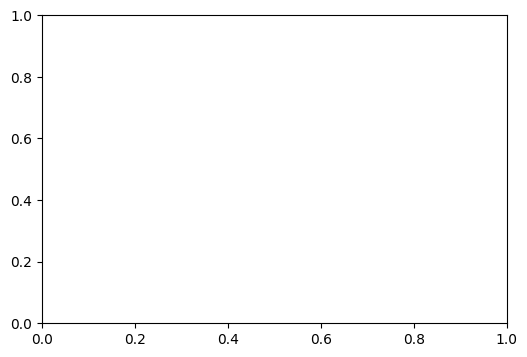

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
# Only for first harmonic, so explude p greater than 10
p_max = 8
#powers = [0.8815, 0.8815, 2.87901, 2.09385]
powers = np.ones(len(datasets))

# Maxwellian
p_mask_M    = np.where(data_M['p_norm'] < p_max)[0]
DRF_int_M = integrate_phasespace(data_M['DRF_pp'][:, p_mask_M, :], data_M['p_norm'][p_mask_M], data_M['ksi0'], data_M['psi'])
# EDFs
p_mask_EDF  = np.where(data_EDF['p_norm'] < p_max)[0]
DRF_int_EDF = integrate_phasespace(data_EDF['DRF_pp'][:, p_mask_EDF, :], data_EDF['p_norm'][p_mask_EDF], data_EDF['ksi0'], data_EDF['psi'])
p_mask_C3PO = np.where(data_C3PO['p_norm'] < p_max)[0]
DRF_int_C3PO = integrate_phasespace(data_C3PO['DRF_pp'][:, p_mask_C3PO, :], data_C3PO['p_norm'][p_mask_C3PO], data_C3PO['ksi0'], data_C3PO['psi'])
# LUKE-C3PO
p_mask_luke = np.where(luke_c3po['p'] < p_max)[0]
DRF_int_luke = integrate_phasespace(luke_c3po['DRF_pp'][:, p_mask_luke, :], luke_c3po['p'][p_mask_luke], luke_c3po['xi'], luke_c3po['psi'])  

#Devide by powers to get same scale for all datasets (since they have different beam powers)
DRF_int_M /= powers[1]
DRF_int_EDF /= powers[2]
DRF_int_C3PO /= powers[3]
DRF_int_luke /= powers[0]


ax.plot(np.sqrt(data_M['psi']), DRF_int_M, label='WKBeam MJ', color='C0', ls='-')
ax.plot(np.sqrt(data_EDF['psi']), DRF_int_EDF, label='WKBeam EDF (1)', color='C1', ls='--')
ax.plot(np.sqrt(data_C3PO['psi']), DRF_int_C3PO, label='WKBeam EDF (4)', color='C2', ls=':')
ax.plot(np.sqrt(luke_c3po['psi']), DRF_int_luke, label='LUKE-C3PO ref.', color='k', ls='-', lw=0.8)


ax.set_xlabel(r'$\rho_{\psi}$', fontsize=13)
ax.set_ylabel(r'$\int\int D_{pp}^{2nd}$ (a.u.)', fontsize=13)
ax.set_xlim(0)
ax.set_ylim(0)
ax.legend(fontsize=9)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(output_dir + '/QL_peak_Dpp_vs_rho.png', dpi=150)
plt.show()

## Per-psi D_pp — absolute values

Columns: **WKBeam MJ** | **WKBeam EDF (lin.)** | **WKBeam EDF (C3PO)**  
White contours = LUKE-C3PO reference.  Red dashed = trapping boundary.

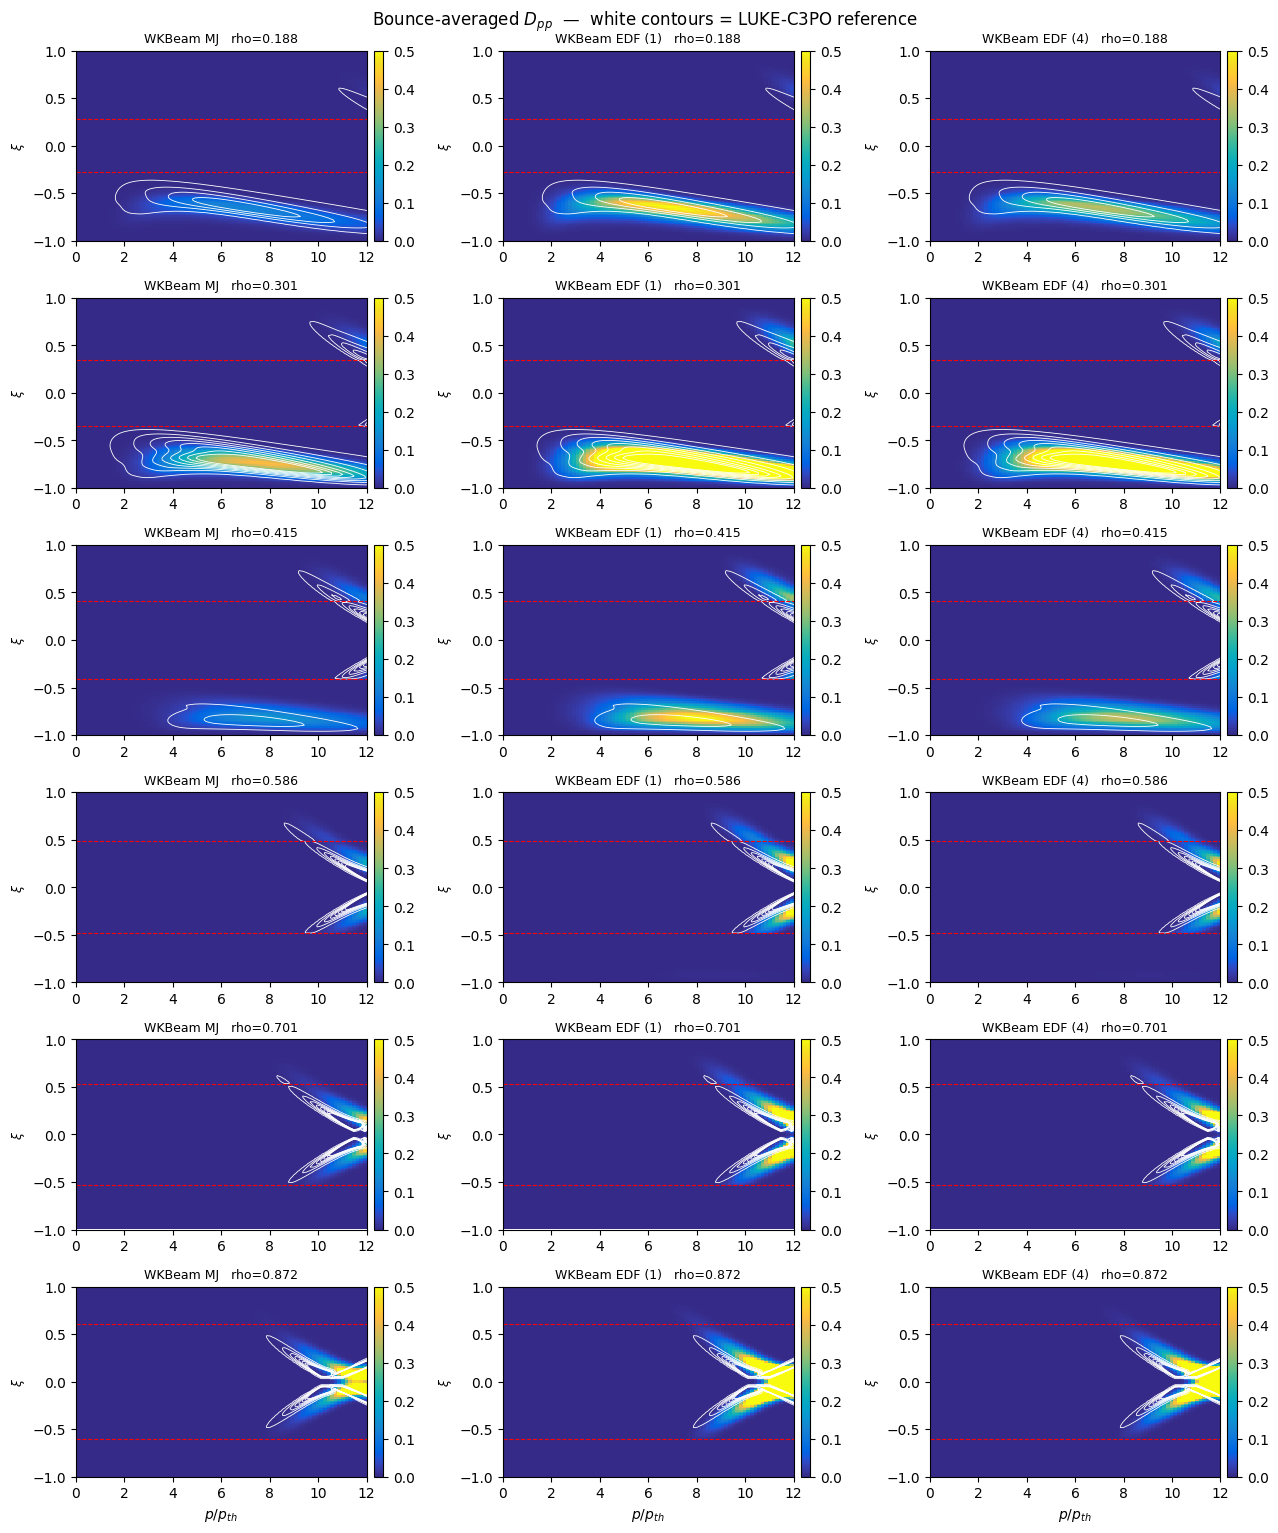

In [ ]:
p_max = 12.0

psi    = data_M['psi']
ksi0   = data_M['ksi0']
p_norm = data_M['p_norm']

psi_indices = np.linspace(2, len(psi) - 2, 6, dtype=int)

vmax = max(np.max(data_M['DRF_pp']), np.max(data_EDF['DRF_pp']),
           np.max(data_C3PO['DRF_pp']))
vmax = 0.5
contour_levels = np.linspace(0.05 * vmax, vmax, 8)

wkb_runs = [
    (data_M,    'WKBeam MJ'),
    (data_EDF,  'WKBeam EDF (1)'),
    (data_C3PO, 'WKBeam EDF (4)'),
]

fig, axes = plt.subplots(len(psi_indices), 3,
                         figsize=(13, 2.6 * len(psi_indices)))
fig.suptitle(r'Bounce-averaged $D_{pp}$  —  white contours = LUKE-C3PO reference',
             fontsize=12)

for row, ipsi in enumerate(psi_indices):
    rho_val = np.sqrt(psi[ipsi])
    trap    = data_M['Trapksi0'][ipsi]
    D_ref   = luke_c3po['DRF_pp'][:, :, ipsi]

    for col, (d, title) in enumerate(wkb_runs):
        ax = axes[row, col]
        D = d['DRF_pp'][:, :, ipsi]
        im = ax.pcolormesh(p_norm, ksi0, D,
                           cmap=parula_map, vmin=0, vmax=vmax, shading='auto')
        ax.contour(p_norm, ksi0, D_ref,
                   levels=contour_levels, colors='white', linewidths=0.6)
        ax.axhline( trap, color='r', lw=0.8, ls='--')
        ax.axhline(-trap, color='r', lw=0.8, ls='--')
        ax.set_xlim(0, p_max)
        ax.set_ylim(-1, 1)
        ax.set_ylabel(r'$\xi$', fontsize=9)
        ax.set_title(f'{title}   rho={rho_val:.3f}', fontsize=9)
        plt.colorbar(im, ax=ax, pad=0.02)

for ax in axes[-1, :]:
    ax.set_xlabel(r'$p/p_{th}$', fontsize=10)

plt.tight_layout()
plt.savefig(output_dir + '/QL_Dpp_per_psi_absolute.png', dpi=150)
plt.show()

## Per-psi D_pp — ratios

Columns: **EDF (lin.) / MJ** | **EDF (C3PO) / MJ** | **WKBeam EDF (C3PO) / LUKE-C3PO**  
Ratio only shown where the denominator exceeds 0.1 % of its global maximum.

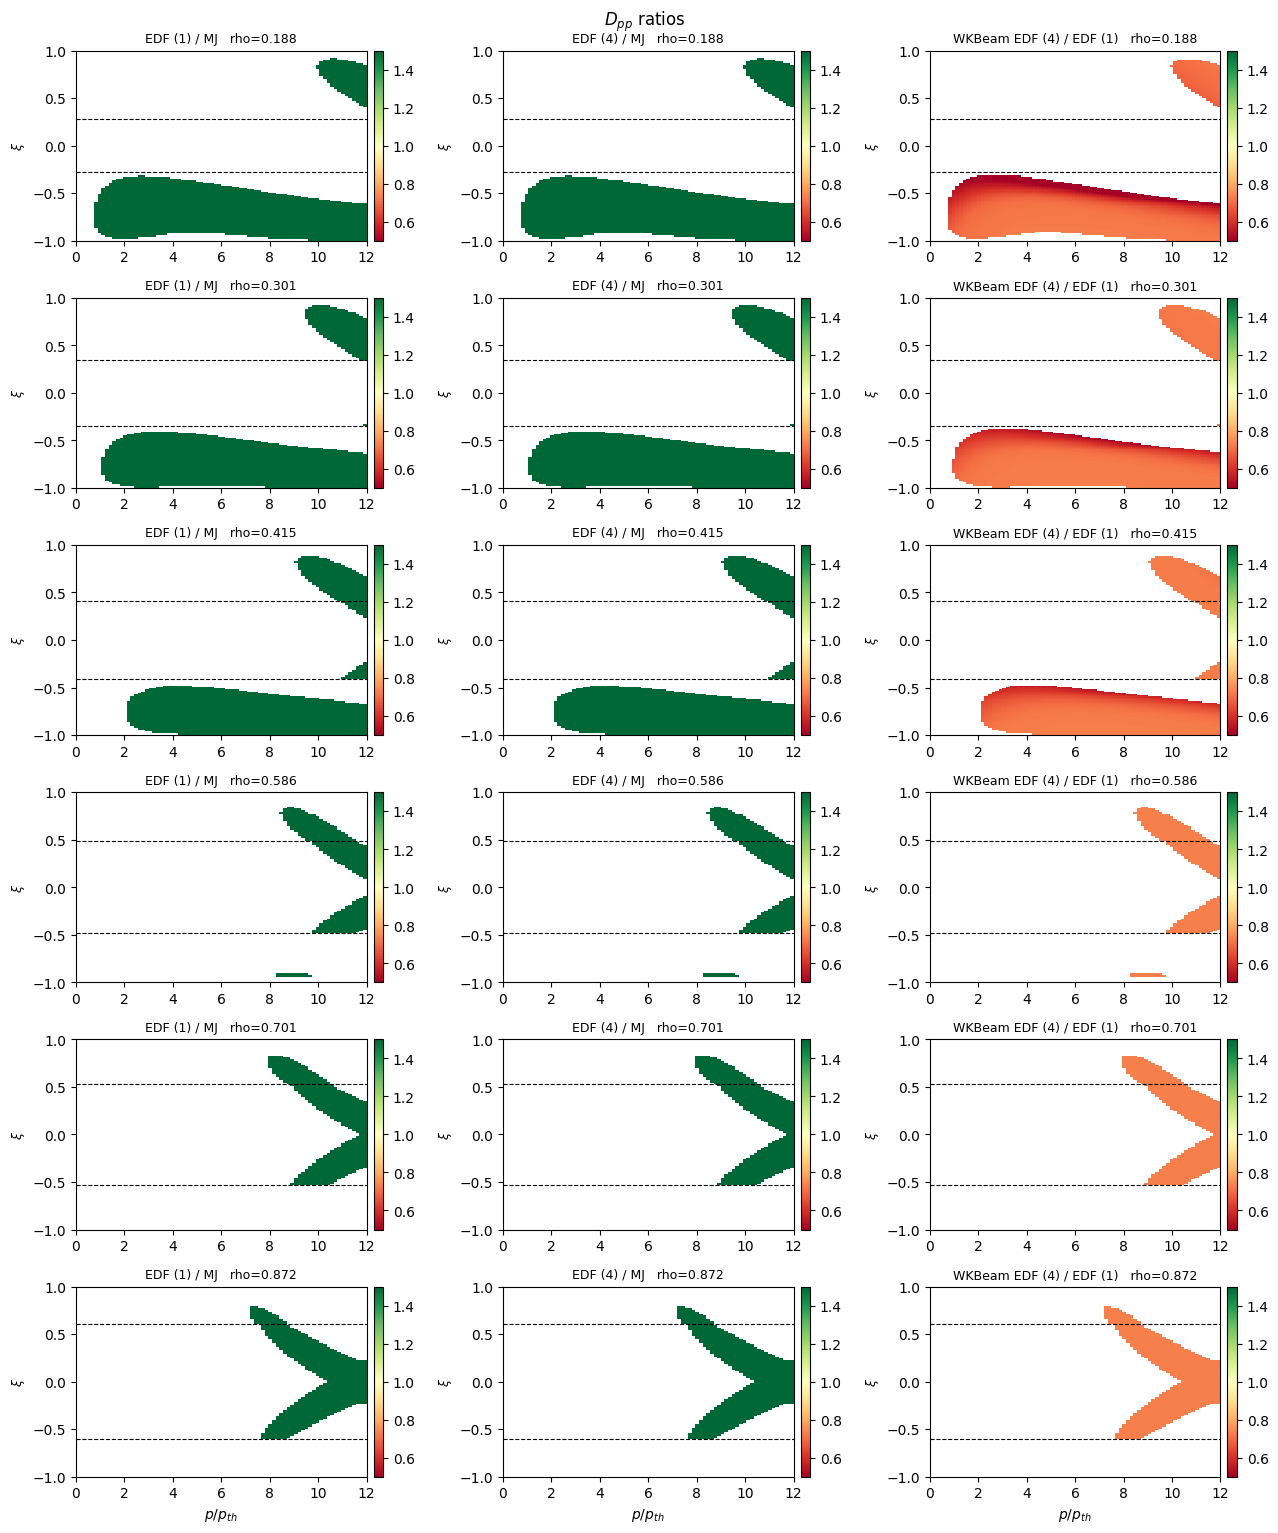

In [ ]:
ratio_specs = [
    (data_EDF,  data_M,    'EDF (1) / MJ'),
    (data_C3PO, data_M,    'EDF (4) / MJ'),
    (data_C3PO, data_EDF, 'WKBeam EDF (4) / EDF (1)'),
]

fig, axes = plt.subplots(len(psi_indices), 3,
                         figsize=(13, 2.6 * len(psi_indices)))
fig.suptitle(r'$D_{pp}$ ratios', fontsize=12)

for row, ipsi in enumerate(psi_indices):
    rho_val = np.sqrt(psi[ipsi])
    trap    = data_M['Trapksi0'][ipsi]

    for col, (d_num, d_den, title) in enumerate(ratio_specs):
        ax = axes[row, col]
        D_num = d_num['DRF_pp'][:, :, ipsi]
        D_den = d_den['DRF_pp'][:, :, ipsi]
        threshold = 1e-3 * np.max(D_den)
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = np.where(D_den > threshold, D_num / D_den, np.nan)
        im = ax.pcolormesh(p_norm, ksi0, ratio,
                           cmap='RdYlGn', vmin=0.5, vmax=1.5, shading='auto')
        ax.axhline( trap, color='k', lw=0.8, ls='--')
        ax.axhline(-trap, color='k', lw=0.8, ls='--')
        ax.set_xlim(0, p_max)
        ax.set_ylim(-1, 1)
        ax.set_ylabel(r'$\xi$', fontsize=9)
        ax.set_title(f'{title}   rho={rho_val:.3f}', fontsize=9)
        plt.colorbar(im, ax=ax, pad=0.02)

for ax in axes[-1, :]:
    ax.set_xlabel(r'$p/p_{th}$', fontsize=10)

plt.tight_layout()
plt.savefig(output_dir + '/QL_Dpp_per_psi_ratios.png', dpi=150)
plt.show()

## D_pp in (p_par, p_perp) at selected rho

/tmp/ipykernel_294517/1588340112.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(Ppar, Pper, D,


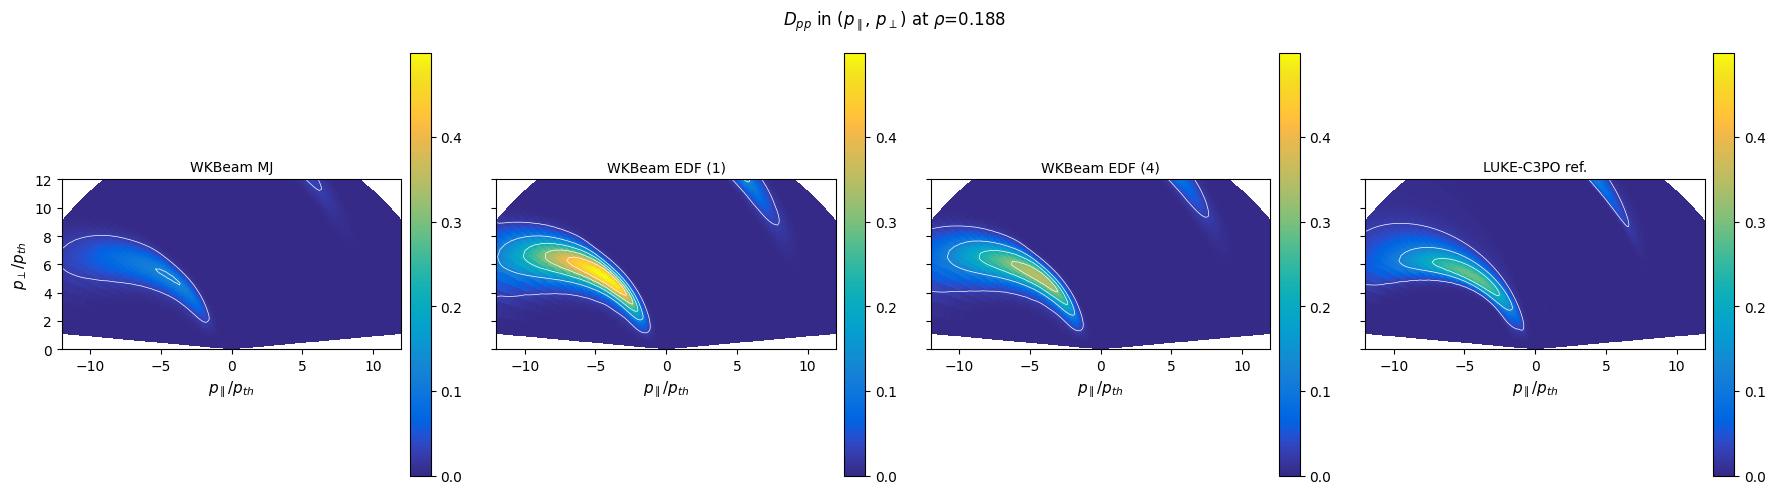

In [ ]:
rho_goal = 0.2
ipsi    = np.argmin(np.abs(np.sqrt(data_M['psi']) - rho_goal))
rho_val = np.sqrt(data_M['psi'][ipsi])

Pnorm, Ksi0 = np.meshgrid(data_M['p_norm'], data_M['ksi0'])
Ppar = Pnorm * Ksi0
Pper = Pnorm * np.sqrt(1 - Ksi0**2)

datasets = [
    (data_M['DRF_pp'][:,:,ipsi],    'WKBeam MJ'),
    (data_EDF['DRF_pp'][:,:,ipsi],  'WKBeam EDF (1)'),
    (data_C3PO['DRF_pp'][:,:,ipsi], 'WKBeam EDF (4)'),
    (luke_c3po['DRF_pp'][:,:,ipsi], 'LUKE-C3PO ref.'),
]

vmax_local = max(np.max(D) for D, _ in datasets[:3])   # exclude LUKE-C3PO from color scaling
contour_levels = np.linspace(0.05 * vmax_local, vmax_local, 6)

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle(rf'$D_{{pp}}$ in $(p_\parallel,\,p_\perp)$ at $\rho$={rho_val:.3f}',
             fontsize=12)

for ax, (D, label) in zip(axes, datasets):
    im = ax.pcolormesh(Ppar, Pper, D,
                       cmap=parula_map, vmin=0, vmax=vmax_local, shading='auto')
    ax.contour(Ppar, Pper, D, levels=contour_levels, colors='white', linewidths=0.5)
    ax.set_xlim(-p_max, p_max)
    ax.set_ylim(0, p_max)
    ax.set_xlabel(r'$p_\parallel / p_{th}$', fontsize=11)
    ax.set_title(label, fontsize=10)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, pad=0.02)

axes[0].set_ylabel(r'$p_\perp / p_{th}$', fontsize=11)

plt.tight_layout()
plt.savefig(output_dir + f'/QL_Dpp_ppar_pperp_rho{rho_val:.2f}.png', dpi=150)
plt.show()

## D_pp integrated over pitch angle

For each selected $\rho$, plots $\int_{-1}^{1} D_{pp}(p,\xi)\,d\xi$ vs $p/p_{th}$ for all four cases. The integral gives the momentum-dependent diffusion strength averaged over pitch angle.

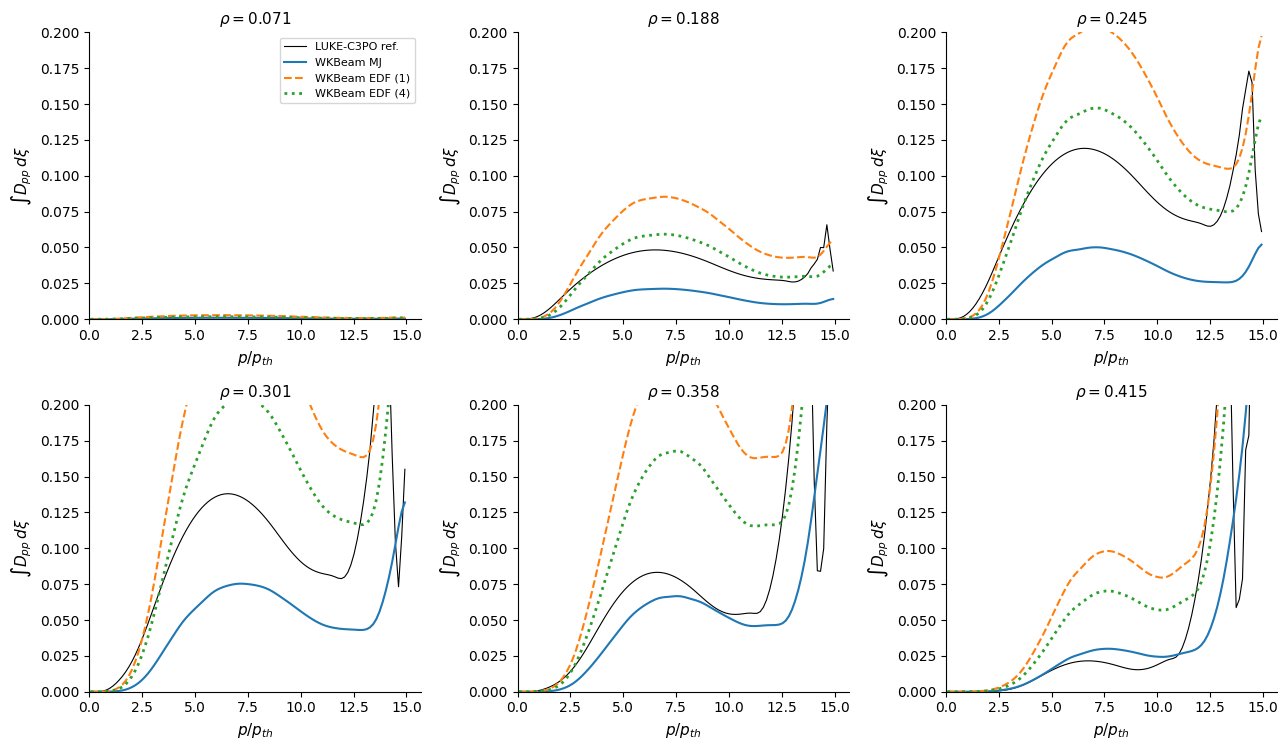

In [ ]:
rho_goals = np.linspace(0.1, 0.4, 6)

psi    = data_M['psi']
ksi0   = data_M['ksi0']
p_norm = data_M['p_norm']

datasets = [
    (luke_c3po['DRF_pp'], 'LUKE-C3PO ref.',    'k',  '-',  0.8),
    (data_M['DRF_pp'],    'WKBeam MJ',         'C0', '-',  1.5),
    (data_EDF['DRF_pp'],  'WKBeam EDF (1)', 'C1', '--', 1.5),
    (data_C3PO['DRF_pp'], 'WKBeam EDF (4)', 'C2', ':',  2.0),
]
#powers = [0.8815, 0.8815, 2.87901, 2.09385]
powers = np.ones(len(datasets))
n_rho = len(rho_goals)
ncols = 3
nrows = int(np.ceil(n_rho / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows), sharey=False)
axes = axes.flatten()

for ax_idx, rho_goal in enumerate(rho_goals):
    ipsi    = np.argmin(np.abs(np.sqrt(psi) - rho_goal))
    rho_val = np.sqrt(psi[ipsi])
    ax      = axes[ax_idx]
    i = 0
    for DRF_pp, label, color, ls, lw in datasets:
        
        # Integrate over xi (axis 0) at this psi slice
        D_int = np.trapz(DRF_pp[:, :, ipsi], ksi0, axis=0)   # shape (n_p,)
        ax.plot(p_norm, D_int/powers[i], label=label, color=color, ls=ls, lw=lw)
        i += 1

    ax.set_xlim(0, None)
    #ax.set_ylim(0, np.nanmax(np.where(p_norm < 10, D_int, np.nan)) * 1.2)
    ax.set_ylim(0, 0.2)
    ax.set_xlabel(r'$p / p_{th}$', fontsize=11)
    ax.set_ylabel(r'$\int D_{pp}\,d\xi$', fontsize=11)
    ax.set_title(rf'$\rho = {rho_val:.3f}$', fontsize=11)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    if ax_idx == 0:
        ax.legend(fontsize=8)

for ax in axes[n_rho:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(output_dir + '/QL_Dpp_xi_integrated.png', dpi=150)
plt.show()

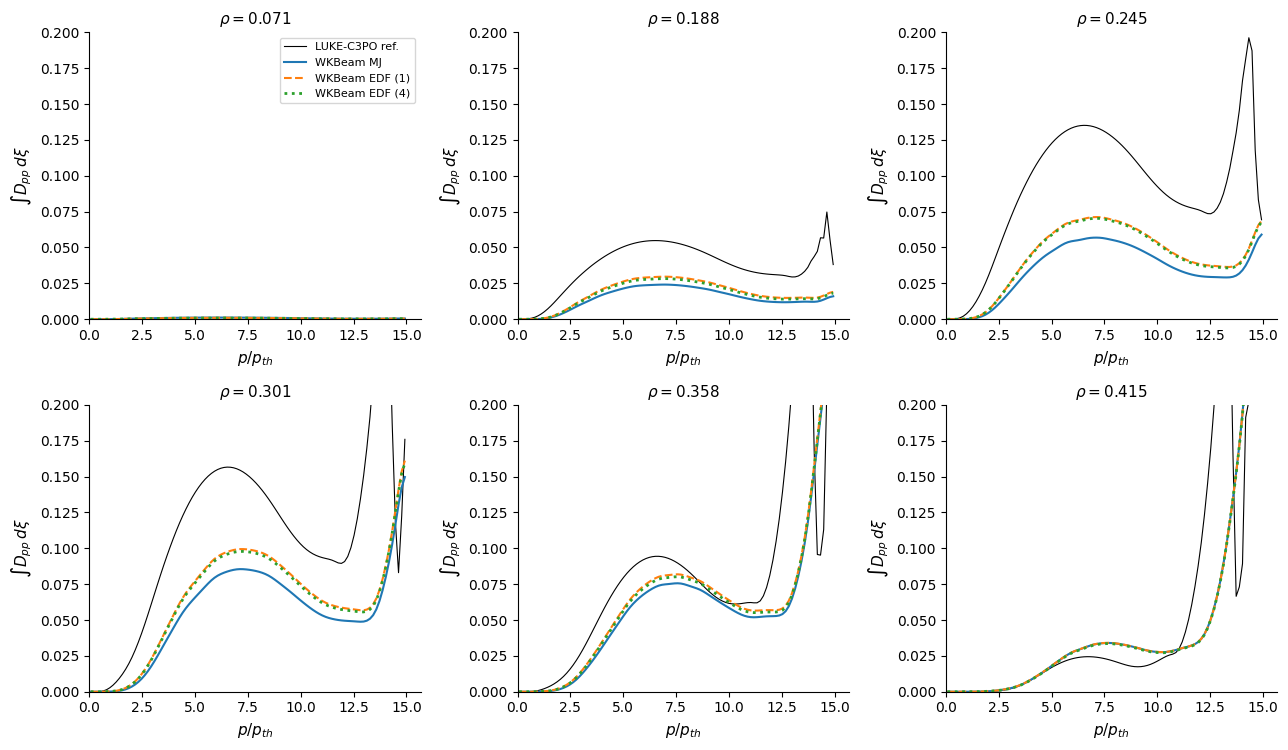

In [ ]:
rho_goals = np.linspace(0.1, 0.4, 6)

psi    = data_M['psi']
ksi0   = data_M['ksi0']
p_norm = data_M['p_norm']

datasets = [
    (luke_c3po['DRF_pp'], 'LUKE-C3PO ref.',    'k',  '-',  0.8),
    (data_M['DRF_pp'],    'WKBeam MJ',         'C0', '-',  1.5),
    (data_EDF['DRF_pp'],  'WKBeam EDF (1)', 'C1', '--', 1.5),
    (data_C3PO['DRF_pp'], 'WKBeam EDF (4)', 'C2', ':',  2.0),
]
powers = [0.8815, 0.8815, 2.87901, 2.09385]
#powers = np.ones(len(datasets))
n_rho = len(rho_goals)
ncols = 3
nrows = int(np.ceil(n_rho / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows), sharey=False)
axes = axes.flatten()

for ax_idx, rho_goal in enumerate(rho_goals):
    ipsi    = np.argmin(np.abs(np.sqrt(psi) - rho_goal))
    rho_val = np.sqrt(psi[ipsi])
    ax      = axes[ax_idx]
    i = 0
    for DRF_pp, label, color, ls, lw in datasets:
        
        # Integrate over xi (axis 0) at this psi slice
        D_int = np.trapz(DRF_pp[:, :, ipsi], ksi0, axis=0)   # shape (n_p,)
        ax.plot(p_norm, D_int/powers[i], label=label, color=color, ls=ls, lw=lw)
        i += 1

    ax.set_xlim(0, None)
    #ax.set_ylim(0, np.nanmax(np.where(p_norm < 10, D_int, np.nan)) * 1.2)
    ax.set_ylim(0, 0.2)
    ax.set_xlabel(r'$p / p_{th}$', fontsize=11)
    ax.set_ylabel(r'$\int D_{pp}\,d\xi$', fontsize=11)
    ax.set_title(rf'$\rho = {rho_val:.3f}$', fontsize=11)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    if ax_idx == 0:
        ax.legend(fontsize=8)

for ax in axes[n_rho:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(output_dir + '/QL_Dpp_xi_integrated.png', dpi=150)
plt.show()